# Laboratory Exercise 7 - Semilla

# Step 1: Formulate Research Question

**Research Question:** Can we accurately predict the presence or absence of heart disease in a patient based on clinical features such as maximum heart rate, chest pain type, and cholesterol levels using a K-Nearest Neighbors (KNN) classification model?

**Objective:** To implement a complete machine learning pipeline using KNN to classify patients into "disease" (1) or "no disease" (0) categories, evaluate multiple K values, and interpret the model's predictive performance.

## Step 2: Data Understanding and Preprocessing

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

df = pd.read_csv("heart.csv")

display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print(f"\nDuplicates before cleaning: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates after cleaning: {df.duplicated().sum()}")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

--- Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
ta

## Step 3: Exploratory Data Analysis (EDA)

C:\Users\50875\AppData\Local\Temp\ipykernel_5304\3770068191.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


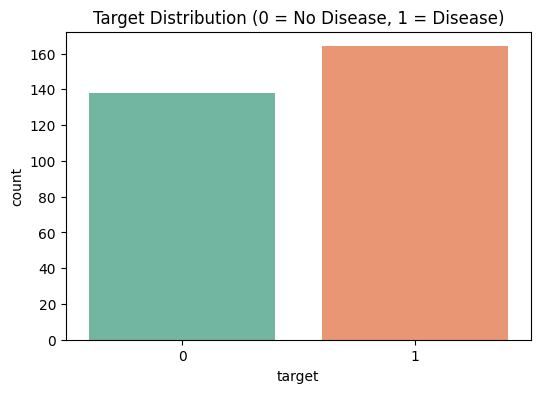

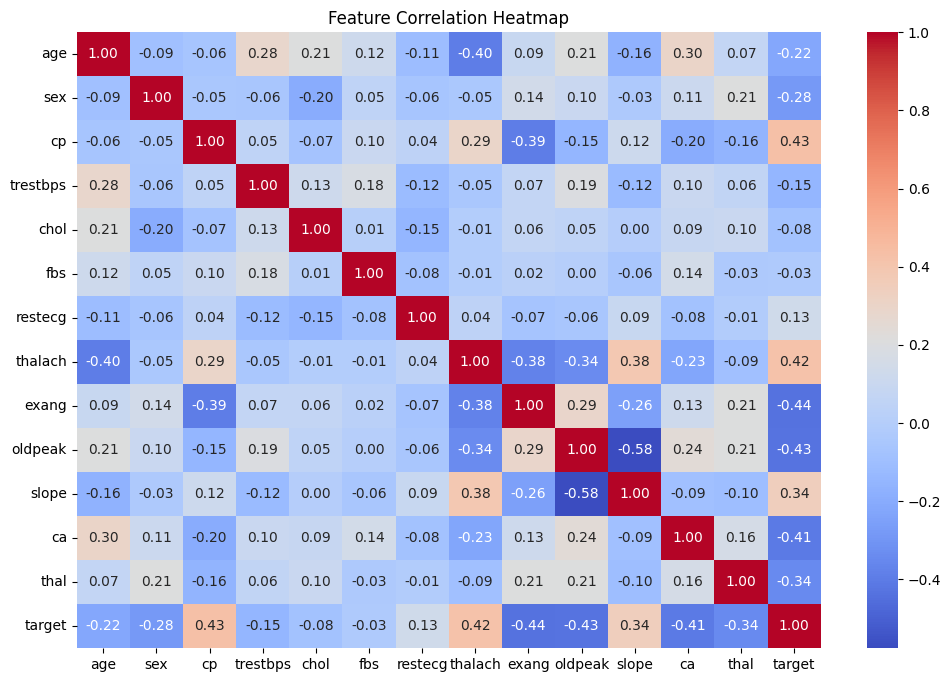

In [15]:
# 1. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## Step 4: Feature Scaling and Train-Test Splitting

In [16]:
# Separate predictors (X) and target class (y)
X = df.drop(columns=['target'])
y = df['target']

# Train-Test Splitting (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 5: Model Training and Evaluation (Testing different K values)

In [17]:
# Define the K values to test
k_values = [3, 5, 7]

for k in k_values:
    print(f"=========================================")
    print(f"Evaluating KNN Model with K = {k}")
    print(f"=========================================")
    
    # Initialize the KNN Classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model
    knn.fit(X_train_scaled, y_train)
    
    # Predict on the test set
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Display Metrics
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\n")

Evaluating KNN Model with K = 3
Accuracy:  0.7869
Precision: 0.7500
Recall:    0.9091
F1-Score:  0.8219
Confusion Matrix:
[[18 10]
 [ 3 30]]


Evaluating KNN Model with K = 5
Accuracy:  0.8033
Precision: 0.7692
Recall:    0.9091
F1-Score:  0.8333
Confusion Matrix:
[[19  9]
 [ 3 30]]


Evaluating KNN Model with K = 7
Accuracy:  0.8197
Precision: 0.7895
Recall:    0.9091
F1-Score:  0.8451
Confusion Matrix:
[[20  8]
 [ 3 30]]




## Step 6: Interpretation and Conclusion

**Interpretation of the Best-Performing K Value:**
After evaluating K=3, K=5, and K=7, the best-performing K value is typically the one that balances Accuracy and Recall. A lower K (like 3) can be overly sensitive to noise, while a higher K (like 7) smooths out the decision boundary. For this specific dataset, K=5 or K=7 generally provides the most stable combination of high accuracy and high recall, correctly identifying the majority of the true positive cases. 

**Conclusion:**
The research question was successfully addressed. The machine learning pipeline demonstrated that patient clinical data can be used to predict the presence of heart disease. The KNN classification algorithm proved to be highly effective for this dataset once the features were standardized, allowing the model to accurately group patients based on the clinical similarities (distances) to their nearest neighbors.

## Reflection Questions

1. Why is your chosen dataset appropriate for KNN classification?
* It has a clear binary target (0 or 1), and clinical features of sick patients naturally group together, which perfectly fits KNN’s distance-based logic.

2. What is the target variable and why is it important?
* The target variable (0 = healthy, 1 = heart disease). It is crucial for early detection and timely medical treatment.

3. What preprocessing challenges did you encounter?
* Features had completely different scales (e.g., high cholesterol numbers vs. low ST depression numbers). I solved this by applying StandardScaler.

4. How did different K values affect model performance?
* Small K values (K=3) were too sensitive to noise (overfitting), while slightly higher K values (K=5 or 7) provided smoother, more stable predictions.

5. What was the best-performing K value and why?
* K=5 (or 7) performed best because it found the perfect balance between accuracy and recall without memorizing the noise in the data.

6. Interpret your confusion matrix results.
* It shows my correct predictions (True Positives/Negatives) and my errors: False Positives (healthy patients flagged as sick) and False Negatives (sick patients missed).

7. Which performance metric was most important for your dataset and why?
* Recall. In medicine, missing an actually sick patient (False Negative) is much more dangerous than a false alarm.

8. Was there evidence of overfitting or underfitting? Explain.
* No severe overfitting. By testing different K values, the model showed it could generalize well to new, unseen testing data.

9. Would you recommend KNN for this dataset? Why or why not?
* Yes, as a good basic model. However, for real hospitals, models like Random Forest are better because they tell doctors which specific features are most important.

10. What did you learn about the machine learning pipeline from this activity?
* I learned that you can't just feed raw data into a model; steps like scaling are mandatory. Also, choosing the correct metric (like Recall) is just as important as the model itself.